In [21]:
import os

os.environ["KERAS_BACKEND"] = "jax"

import random
import io

import kagglehub
import matplotlib.pyplot as plt
from pathlib import Path
import grain.python as grain
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
from sklearn.model_selection import train_test_split
import keras
import seaborn as sns

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [4]:
KH_DATA_PATH = Path(
    kagglehub.dataset_download("zulkarnainsaurav/four-genre-movie-poster-images")
)
DATA_DIR = Path(KH_DATA_PATH) / "four_genre_posters" / "four_genre_posters"

In [5]:
CLASSES = ["Action", "Comedy", "Horror", "Romance"]
N_CLASSES = len(CLASSES)

IMG_SIZE = (380, 562)  # We are going to use the original sz
BATCH_SIZE = 64

In [6]:
def gen(loader):
    for batch in loader:
        yield batch["image"], batch["label"]

In [7]:
class ImageProcessor(grain.MapTransform):
    def map(self, data):
        with open(data["path"], "rb") as f:
            img = Image.open(io.BytesIO(f.read())).convert("RGB")

        img_array = np.array(img).astype(np.float32) / 255.0

        label = data["label"]
        one_hot = np.zeros(N_CLASSES, dtype=np.float32)
        one_hot[label] = 1.0

        return {"image": img_array, "label": one_hot}


transformations = [ImageProcessor(), grain.Batch(BATCH_SIZE)]

In [8]:
def create_loader(files, shuffle=False):
    sampler = grain.IndexSampler(
        len(files), shard_options=grain.NoSharding(), shuffle=shuffle, seed=SEED
    )
    source = grain.MapDataset.source(files)
    return grain.DataLoader(
        data_source=source, operations=transformations, sampler=sampler
    )

In [9]:
ds = []
for i, class_name in enumerate(CLASSES):
    class_dir = DATA_DIR / class_name
    for img_path in class_dir.glob("*.jpg"):
        ds.append({"path": str(img_path), "label": i})

In [10]:
train_f, temp_f = train_test_split(ds, test_size=0.3, stratify=[d["label"] for d in ds])
val_f, test_f = train_test_split(
    temp_f, test_size=0.5, stratify=[d["label"] for d in temp_f]
)

In [11]:
train_loader = create_loader(train_f, shuffle=True)
val_loader = create_loader(val_f)
test_loader = create_loader(test_f)

In [12]:
train_steps = len(train_f) // BATCH_SIZE
val_steps = len(val_f) // BATCH_SIZE

In [13]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(*IMG_SIZE, 3)),
        keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(64, 3, activation="relu"),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(N_CLASSES, activation="softmax"),
    ]
)

In [14]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [15]:
m_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",
        save_best_only=True,
    ),
    keras.callbacks.CSVLogger(filename="train_log.csv", append=False),
]

In [16]:
train_hist = model.fit(
    gen(train_loader),
    steps_per_epoch=train_steps,
    validation_data=gen(val_loader),
    validation_steps=val_steps,
    epochs=10,
    callbacks=m_callbacks,
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.2500 - loss: 1.3747 - val_accuracy: 0.3021 - val_loss: 1.3569
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.3694 - loss: 1.3445 - val_accuracy: 0.5000 - val_loss: 1.3138
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.4308 - loss: 1.2889 - val_accuracy: 0.4167 - val_loss: 1.2748
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.4386 - loss: 1.2380 - val_accuracy: 0.5156 - val_loss: 1.2052
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.4286 - loss: 1.2205 - val_accuracy: 0.5156 - val_loss: 1.1627
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.4710 - loss: 1.1710 - val_accuracy: 0.5052 - val_loss: 1.1881
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.4509 - loss: 1.1781 - val_accuracy: 0.5312 - val_loss: 1.1568
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.4732 - loss: 1.1860 - val_accuracy: 0.5573 - val_loss:

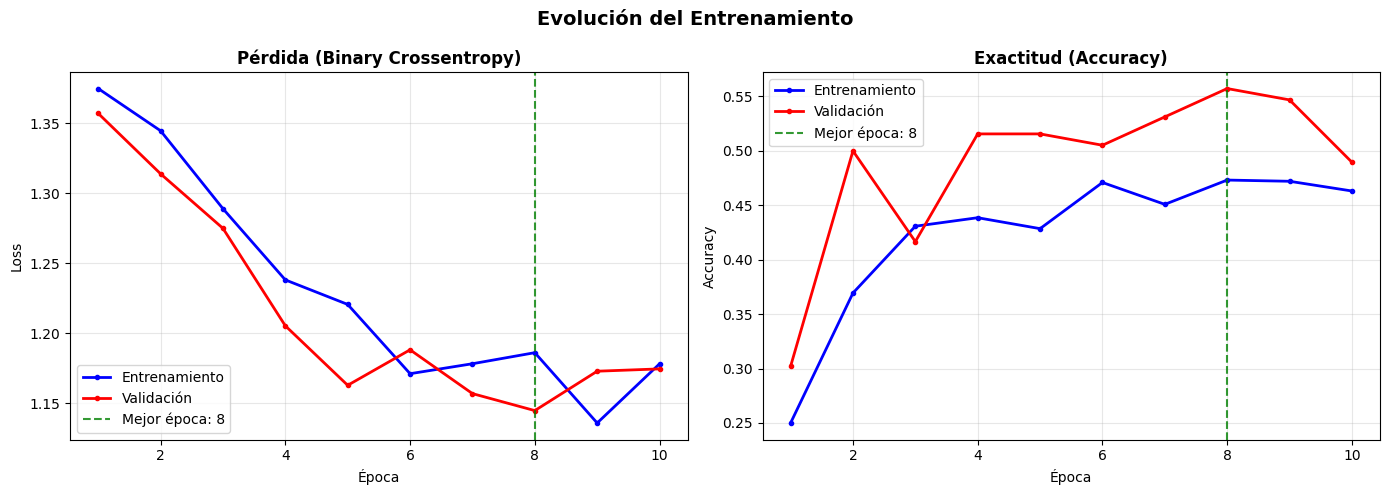

In [17]:
epochs = range(1, len(train_hist.history["loss"]) + 1)
best_epoch = int(np.argmin(train_hist.history["val_loss"])) + 1

_, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    epochs,
    train_hist.history["loss"],
    "b-o",
    markersize=3,
    linewidth=2,
    label="Entrenamiento",
)
axes[0].plot(
    epochs,
    train_hist.history["val_loss"],
    "r-o",
    markersize=3,
    linewidth=2,
    label="Validación",
)
axes[0].axvline(
    x=best_epoch,
    color="green",
    linestyle="--",
    alpha=0.8,
    label=f"Mejor época: {best_epoch}",
)
axes[0].set_title("Pérdida (Binary Crossentropy)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    epochs,
    train_hist.history["accuracy"],
    "b-o",
    markersize=3,
    linewidth=2,
    label="Entrenamiento",
)
axes[1].plot(
    epochs,
    train_hist.history["val_accuracy"],
    "r-o",
    markersize=3,
    linewidth=2,
    label="Validación",
)
axes[1].axvline(
    x=best_epoch,
    color="green",
    linestyle="--",
    alpha=0.8,
    label=f"Mejor época: {best_epoch}",
)
axes[1].set_title("Exactitud (Accuracy)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Evolución del Entrenamiento", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("curvas_entrenamiento.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
test_steps = int(np.ceil(len(test_f) / BATCH_SIZE))
test_loss, test_acc = model.evaluate(gen(test_loader), steps=test_steps, verbose=0)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Predict all test batches in one call (much faster than per-batch predict).
y_prob = model.predict(gen(test_loader), steps=test_steps, verbose=1)
test_preds = np.argmax(y_prob, axis=1)

# Collect true labels with the same number of steps to keep alignment.
y_true_batches = []
for step_idx, (_, y_batch) in enumerate(gen(test_loader)):
    if step_idx >= test_steps:
        break
    y_true_batches.append(np.argmax(y_batch, axis=1))

test_labels = np.concatenate(y_true_batches)

print(classification_report(test_labels, test_preds, target_names=CLASSES))

Test Loss: 1.2051, Test Accuracy: 0.3984
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 346ms/step
              precision    recall  f1-score   support

      Action       0.15      0.08      0.11        60
      Comedy       0.34      0.32      0.33        63
      Horror       0.51      0.82      0.63        77
     Romance       0.35      0.25      0.29        56

    accuracy                           0.40       256
   macro avg       0.34      0.37      0.34       256
weighted avg       0.35      0.40      0.36       256

[[ 5 15 31  9]
 [10 20 19 14]
 [ 5  6 63  3]
 [14 17 11 14]]


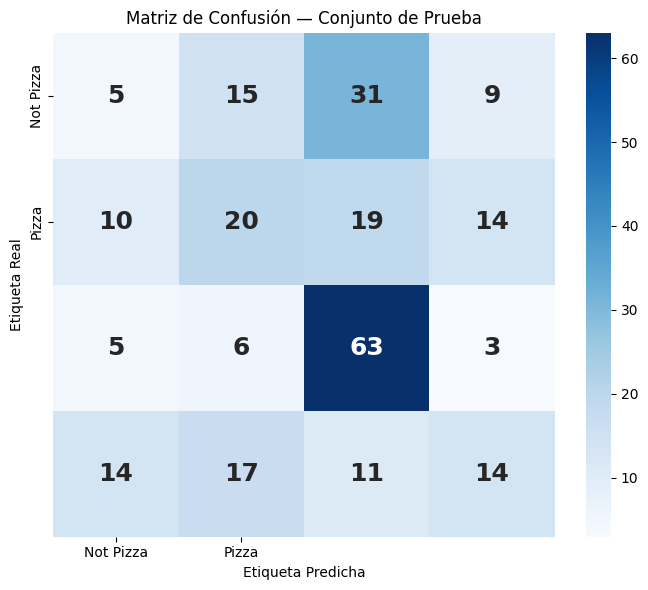

In [22]:
cm = confusion_matrix(test_labels, test_preds, labels=range(len(CLASSES)))
_, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Pizza", "Pizza"],
    yticklabels=["Not Pizza", "Pizza"],
    linecolor="white",
    annot_kws={"size": 18, "weight": "bold"},
    ax=ax,
)
ax.set_title("Matriz de Confusión — Conjunto de Prueba")
ax.set_ylabel("Etiqueta Real")
ax.set_xlabel("Etiqueta Predicha")
plt.tight_layout()
plt.savefig("matriz_confusion.png", dpi=300, bbox_inches="tight")
plt.show()